# MATH40006 In-Course Assessment

# 19 March 2026, 10.10-12:10

## Two Hours

### Answer all questions, submitting your answers as a single Jupyter notebook.

<font color='red'>Note: you will be asked, in Question 3, to create two external files. You need not submit these files.</font>

If your code should hang, first try interrupting the kernel; then try restarting the kernel; then try closing VS Code and reopening.

To carry out this assignment, you may find useful, possibly amongst other things:
 - from the `sympy` module, the functions `symbols`, `exp`, `diff`, `sin`, `Integer`, `lambdify`, `plot` and `randprime`, the constant `pi` and the method `subs`;
 - from the `numpy` module, the function `linspace`;
 - from the `math` module, the functions `gcd`, `ceil` and `sqrt`;
 - from the `pyplot` submodule of `matplotlib`, the functions `plot` and `ylim`;
 - from the `pandas` module, the function `DataFrame`, and the methods `head`, `pivot_table`, `groupby`, `plot` and `to_csv`;
 - from the `pickle` module, the method `dump`.

We recommend that you execute the following cell:

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from random import randint, choice
from time import time
import math

## Question 1 (25 marks)

The following code calculates a (Taylor) power series approximation for $e^x$, around $x=0$, up to and including the term in $x^5$.

In [109]:
x = sp.symbols('x')
f, a = sp.exp(x), 0
series = f.subs(x, a)
fac = 1
for r in range(1, 6):
    f = sp.diff(f, x)
    fac *= r
    series += f.subs(x,a)*(x-a)**r/fac
series

x**5/120 + x**4/24 + x**3/6 + x**2/2 + x + 1

(a) Calculate a similar power series, for $\sin x$ around $x=\pi/4$, up to and including the term in $(x-\pi/4)^5$.

In [110]:
x=sp.symbols('x')
f, a = sp.sin(x), sp.pi/4
series= f.subs(x,a)
fac = 1
for r in range (1,6):
    f = sp.diff(f,x)
    fac*=r
    series += f.subs(x,a)*(x-a)**r/fac
    
series

sqrt(2)*(x - pi/4)**5/240 + sqrt(2)*(x - pi/4)**4/48 - sqrt(2)*(x - pi/4)**3/12 - sqrt(2)*(x - pi/4)**2/4 + sqrt(2)*(x - pi/4)/2 + sqrt(2)/2

3/3

(b) Write a function called `power_series`, which should take as its arguments:
- `f`, which may be assumed to be a SymPy symbolic expression;
- `x`, which may be assumed to be a SymPy symbol;
- `x0`, a keyword-only argument with default value `0`;
- `n`, a keyword-only argument with default value `5`.

It should then return, as a SymPy expression, a power series approximation for `f` around `x=x0`, up to and including the term in $(x-x_0)^n$. (It may be assumed here that `f` is differentiable with respect to `x` at `x=x0` at least `n` times.)

In [111]:
def power_series(f, x, *, x0=0, n=5):
    series =f.subs(x, x0)
    fac=1
    for r in range(1, n+1):
        f=sp.diff(f, x)
        fac*=r
        series+=f.subs(x, x0)*(x-x0)**r/fac
    return series


5/5

(c) Test your function on the above two examples, and also on $\displaystyle{\frac{1}{1+x^2}}$, around $x=0$, up to the term in $x^{10}$.

In [112]:
Expr_1 = power_series(sp.exp(x), x, n=5)
Expr_2 = power_series(sp.sin(x), x, x0=sp.pi/4, n=5)
Expr_3 = power_series(1/(1+x**2), x, n=10)
Expr_1

x**5/120 + x**4/24 + x**3/6 + x**2/2 + x + 1

In [104]:
Expr_2

sqrt(2)*(x - pi/4)**5/240 + sqrt(2)*(x - pi/4)**4/48 - sqrt(2)*(x - pi/4)**3/12 - sqrt(2)*(x - pi/4)**2/4 + sqrt(2)*(x - pi/4)/2 + sqrt(2)/2

In [105]:
Expr_3

-x**10 + x**8 - x**6 + x**4 - x**2 + 1

3/3

The following code re-runs the calculation of the power series for $e^x$ from above, then uses `lambdify` to create NumPy-compatible functions for $e^x$ and for the series, which are then plotted on the same pair of axes.

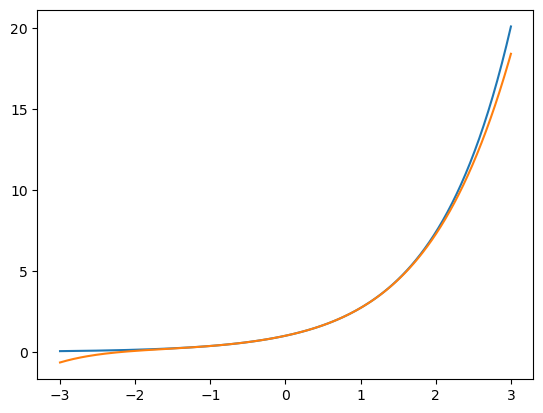

In [8]:
x = sp.symbols('x')
f, a = sp.exp(x), 0
series = f.subs(x, a)
fac = 1
for r in range(1, 6):
    f = sp.diff(f, x)
    fac *= r
    series += f.subs(x,a)*(x-a)**r/fac
f_lambda = sp.lambdify(x, f, "numpy")
series_lambda = sp.lambdify(x, series, "numpy")
x_values = np.linspace(-3, 3, 200)
plt.plot(x_values, f_lambda(x_values), x_values, series_lambda(x_values))

(d) Write a function called `power_series_plot1`, which should take as its arguments:
- `f`, which may be assumed to be a SymPy symbolic expression;
- `xrange`, which may be assumed to be a 3-tuple consisting of a SymPy symbol and a minimum and maximum value, such as `(x, -2, 2)`;
- `x0`, a keyword-only argument with default value `0`;
- `n`, a keyword-only argument with default value `5`;
- `nx`, a keyword-only argument with default value `200`;
- `ylim`, a keyword-only argument with default value `None`.

It should then use the above method, based on `lambdify` and the `plot` function from `matplotlib.pyplot`, to plot, on the same pair of axes, both `f` and its power series approximation, at `x=x0`, up to and including the term in $(x-x_0)^n$. (You should, if possible, <em>call</em> your `power_series` function rather than duplicating its functionality here.)

For `xrange` given as `(x, xmin, xmax)`, the plot should be for values of `x` between `xmin` and `xmax` inclusive. There should be `nx` such values.

If `ylim` is given as `None`, then the automatic $y$-range that `plot` chooses should be used. But if, instead, `ylim` is given as the tuple `(ymin, ymax)`, then the instruction
```python
plt.ylim(ylim)
```
should be used to set the $y$-range.

In [14]:
def power_series_plot1(f, xrange, *, x0=0, n=5, nx=200, ylim=None):
    series = power_series(f, x, x0=x0, n=n)
    f_lambda = sp.lambdify(x, f, 'numpy')
    series_lambda = sp.lambdify(x, series, 'numpy')
    x_values = np.linspace(xrange[1], xrange[2],nx)
    if ylim==None:
        plt.plot(x_values, f_lambda(x_values), x_values, series_lambda(x-values))
    else:
        plt.ylim(ylim)
        plt.plot(x_values, f_lambda(x_values), x_values, series_lambda(x_values))
        




<font color='red'>4/5:

-1 mark: x is the first element/symbol of xrange</font>

Typo inside if ylim==None: statement, but correct in else: statement

for brevity plot line after if statement

(e) Using your function, create a plot of $\displaystyle{\frac{1}{1+x^2}}$, together with its power series approximation around $x=0$, up to and including the term in $x^{10}$. Use `200` $x$-values between $-2$ and $2$ inclusive, and set `ylim` to `(-1, 2)`.

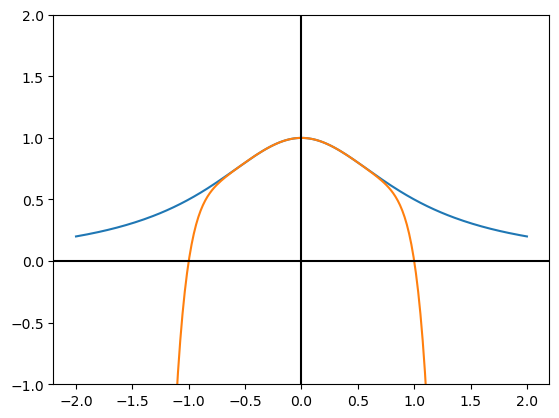

In [120]:
power_series_plot1(1/(1+x**2), (x, -2, 2), n=10, ylim=(-1,2))
plt.axhline(color='black')
plt.axvline(color='black')

2/2

(f) Write a function called `power_series_plot2`, which should take as its arguments:
- `f`, which may be assumed to be a SymPy symbolic expression;
- `xrange`, which may be assumed to be a 3-tuple consisting of a SymPy symbol and a minimum and maximum value;
- `x0`, a keyword-only argument with default value `0`;
- `n`, a keyword-only argument with default value `5`;
- `ylim`, a keyword-only argument with default value `None`.

It should then use the `plot` function <em>from SymPy</em>, together with the `extend` and `show` methods, to plot, on the same pair of axes, both `f` and its power series approximation, at `x=x0`, up to and including the term in $(x-x_0)^n$.

For `xrange` given as `(x, xmin, xmax)`, the plot should be for values of `x` between `xmin` and `xmax` inclusive. (<b>Note</b>: no `nx` is needed; `plot` will take care of the number of $x$-values automatically.)

If `ylim` is given as `None`, then the automatic $y$-range that `plot` chooses should be used. But if, instead, `ylim` is given as the tuple `(ymin, ymax)`, then the $y$-range should be set accordingly. (<b>Note</b>: this may all be done by simply setting `ylim=ylim` within the argument sequence for `plot`.)

In [23]:
def power_series_plot2(f, xrange, *, x0=0, n=5, ylim=None):
    series = power_series(f, x, x0=x0, n=n)
    if ylim==None:
        p1= sp.plot(f, xrange, show=False)
        p2=sp.plot(series, xrange, show=False)
        p1.extend(p2)
        p1.show()
    else:
        p1=sp.plot(f, xrange, ylim=ylim, show=False)
        p2=sp.plot(series, xrange, ylim=ylim, show=False)
        p1.extend(p2)
        p1.show()



5/5

Similarly to before x corresponds to first element of xrange

No need for if statement

(g) Using your function, create a plot of $\displaystyle{\frac{1}{1+x^2}}$, together with its power series approximation around $x=0$, up to and including the term in $x^{10}$. Use $x$-values between $-2$ and $2$ inclusive, and set `ylim` to `(-1, 2)`.

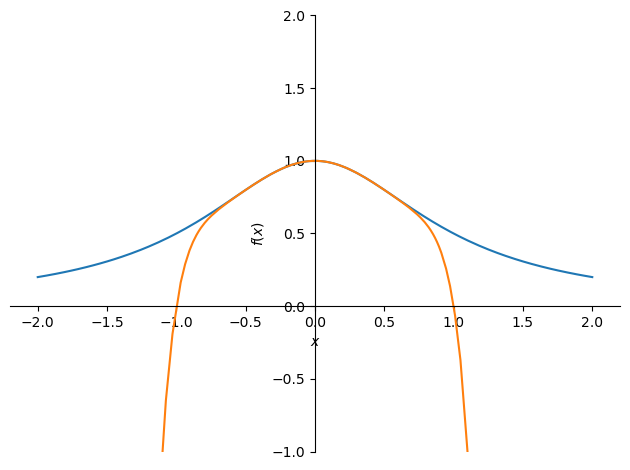

In [24]:
power_series_plot2(1/(1+x**2), (x,-2, 2), n=10, ylim=(-1,2))

2/2

Q1: 24/25

## Question 2 (45 marks)

This question concerns the <b>discrete logarithm problem</b> in modular arithmetic. Here, one is given a modulus $n$, and two integers $g$ and $h$, where $0 < g < n$ and $0 < h < n$, and asked to find a value of $x$, where $0<x<n$, such that 

$$g^x \equiv h\quad({\rm mod}\,n).$$

(The value of $x$ may or may not be unique.)

### (i) 

Given `g`, `h` and `n`, the simplest way to solve a discrete logarithm problem, although it is a desperately inefficient method, is simply to start with
```python
gpower = g
```
and then execute
```python
gpower = (gpower * g) % n
```
repeatedly, keeping count of the number of iterations. If at any stage `gpower` is equal to `h`, the process should terminate, and the value of `x` can then be calculated from the number of iterations.

The following code uses this method to find integer $x$ such that $93^x\equiv 24$ (mod $151$) (provided such an $x$ exists, which in this case it does).

In [26]:
g, h, n = 93, 24, 151
gpower = g
for x in range(1, n):
    if gpower == h:
        break
    gpower = (gpower * g) % n
print(x)

99


(a) Using Python, check that for the value of $x$ that this code calculates, it is indeed the case that $93^{x} \equiv 24$ (mod $151$). There will be a mark for doing this fairly efficiently.

In [27]:
pow(93,99,151)

24

2/2

(b) Write a function `discrete_log1`, which takes as its arguments the ints `g`, `h` and `n`, and returns an integer value of `x`, greater than `0` but less than `n`, such that $g^x\equiv h$ (mod $n$). You may assume that `g` and `h` lie strictly between `0` and `n`. If no such value of `x` exists, the function should return the string `"failed"`; if there are more than one, it may return any one of them.

Give your function a short docstring.

In [32]:
def discrete_log1(g, h, n):
    gpower= g
    for x in range(1,n):
        if gpower==h:
            return(x)
        gpower = (gpower*g)%n
    return "failed"
    

<font color='red'>4/5

-1 mark: no docstring</font>

(c) Test your function on the following values of `g`, `h` and `n`:
- `93`, `24`, `151` (should return `99`);
- `92`, `24`, `151` (should return `"failed"`)

In [36]:
test_1 = discrete_log1(93, 24, 151)
test_2 = discrete_log1(92, 24, 151)
test_1, test_2

(99, 'failed')

2/2

(d) For a given value of $n$, in the worst case, how many iterations are necessary to solve a discrete logarithm problem using this method? Briefly justify your answer.

n-1 iterations, as the for loop iterates through n-1 values. in the worst case, will only return on final iteration

2/2

(e) For a given value of $n$, in the best case, how many iterations are necessary to solve a discrete logarithm problem using this method? Briefly justify your answer.

1 iteration as the value of x for a given g, h and n might be 1. This will be achieved on first iterate of loop.

2/2

(f) If $l$ is the number of binary digits in $n$, describe the dependence of the "worst case" number of iterations on $l$ using big $O$ notation, giving brief reasons for your answer.

# O(e^l)
 n is approx order 2^l and dependence on n is o(n) so it's order 2^l. We drop the 2 and go to a general base e, as big O is about 'type of behaviour' which is exponential here

2/2

(h) Write and test a <em>recursive</em> version of `discrete_log1`, called `discrete_log1_rec`, which should take as its arguments `g`, `h` and `n`, as well as two keyword-only arguments, `x` (with default value `1`) and `gpower` (with default value `None`).

- If `gpower` has the value `None`, it should be given the value `g%n`;
- If `gpower == h`, the function should return the value of `x`;
- If `x >= n`, the function should return `"failed"`;
- Otherwise, the function should call itself recursively, with the same values of `g`, `h` and `n`, but with `x` set to `x+1` and `gpower` set to `(gpower*g)%n`.

In [38]:
def discrete_log1_rec(g, h, n, *, x = 1, gpower = None):
    if gpower ==None:
        gpower = g%n
    if gpower == h:
        return x
    if x >=n:
        return "failed"
    return discrete_log1_rec(g, h, n, x=x+1, gpower= (gpower*g)%n)
test_1 = discrete_log1_rec(93, 24, 151)
test_2 = discrete_log1_rec(92,24, 151)
test_3 = discrete_log1_rec(93, 24, 151, x=30, gpower=24)
test_4 = discrete_log1_rec(92, 24, 151, x=200)
test_5 = discrete_log1_rec(25, 38, 452)
test_1, test_2, test_3, test_4, test_5
 

(99, 'failed', 30, 'failed', 'failed')

<font color='red'>6/7

-1 mark: no docstring</font>

### (ii)

A more complicated, but less inefficient, method for calculating discrete logarithms is called <b>Shanks' Babystep-Giantstep algorithm</b>.

That goes like this. For given values of `g`, `h` and `n`, to find `x` such that $g^x \equiv h$ (mod $n$):
- To initialize:
  - Let `m` be $\left\lceil \sqrt{n} \right\rceil$, the least integer greater than or equal to $\sqrt{n}$;
  - Let `y` be the inverse of the residue, mod $n$, of $g^{m}$ (this can be done using `y = pow(g, -m, n)`);
  - Define `el1 = 1` and `el2 = h`;
  - Set up lists `list1 = [1]` and `list2 = [h]`.
- Then iterate the following steps until <em>either</em> `el1` is in `list2` <em>or</em> `el2` is in `list1`:
  - Set `el1 = (el1 * g) % n` and append `el1` to `list1`;
  - Set `el2 = (el2 * y) % n` and append `el2` to `list2`.
- When the process terminates, either `el1` is in `list2` or `el2` is in `list1`. In the former case, the  value of `x` is `list1.index(el1) + m*list2.index(el1)`. In the latter, it is `list1.index(el2) + m*list2.index(el2)`.

(<b>Note</b>: if `m-1` iterations have taken place, with the process not having terminated, no discrete logarithm exists and the method therefore fails.)

The following is some initialization code for the case `g, h, n = 93, 24, 151`:

In [141]:
g, h, n = 93, 24, 151
m = 13 # (since 12**2 < 151 but 13**2 >= 151)
y = pow(g, -m, n) # Calculates the inverse of g**m mod n
el1, el2 = 1, h
list1, list2 = [1], [h]

(a) Write some code that performs the remaining steps of the algorithm, and check that $x=99$.

(You may want to ensure that your loop terminates after `m-1` iterations, but as this particular discrete logarithm problem definitely has a solution, this is optional.)

In [142]:
while (not el1 in list2) and (not el2 in list1):
    el1 = (el1*g)%n
    el2 = (el2*y)%n 
    list1.append(el1)
    list2.append(el2)
if el1 in list2:
    x = list1.index(el1) +m*list2.index(el1)
else: 
    x= list1.index(el2) + m*list2.index(el2)
print(x)
    



99


5/5

(b) Write a function `discrete_log2` that takes as its arguments ints `g`, `h` and `n`, and uses Shanks' Babystep-Giantstep algorithm to find an integer value of `x`, greater than `0` but less than `n`, such that $g^x \equiv h$ (mod $n$). As before, you may assume that `g` and `h` lie strictly between `0` and `n`.

Note: you will need to think of a way to calculate `m`; the `ceil` function from `math` may be helpful here.

Note too that there are two ways the algorithm can fail. One is if $\gcd(g, n)\neq 1$; that would make the line 
```python
y = pow(g, -m, n)
```
generate an error message, so your code should test for this problem before executing that line (use `gcd` from the `math` module). The other is if `m-1` full iterations have taken place without the process terminating. In either case, your function should return `"failed"`. If there is more than one valid value, it may return any one of them.

Give your function a short docstring.

In [127]:
def discrete_log2(g, h, n):
    """
    Shanks' babystep-giantstep algorithm to find an integer x greater than 0 but less than n such that g**x = h modn
    """
    if math.gcd(g, n) !=1:
        return "failed"
    m = math.ceil(math.sqrt(n))
    y= pow(g, -m, n)
    el1, el2, = 1, h
    list1, list = [1], [h]
    iter_count= 0
    while (not el1 in list2) and (not el2 in list1) and iter_count < (m-1):
        iter_count +=1
        el1 = (el1*g)%n 
        el2 =(el2*y)%n 
        list1.append(el1)
        list2.append(el2)
    if iter_count == m-1:
        return "failed"
    elif el1 in list2:
        return list1.index(el1) + m*list2.index(el1)
    elif el2 in list2:
        return list1.index(el2) + m*list2.index(el2)
    


<font color='red'>7/8

-1 mark: typo in list2 initiation and fail if statement needs to be after other checks</font>

(c) Test your function on the following values of `g`, `h` and `n`:
- `93`, `24`, `151` (should return `99`);
- `92`, `24`, `151` (should return `"failed"`);
- `94`, `24`, `152` (should return `"failed"`).

In [130]:
# discrete had been misspelt as discret so have changed it in fucntion def
test_1 = discrete_log2(93, 24, 151)
test_2 = discrete_log2(92, 24, 151)
test_3 = discrete_log2(94, 24, 152)
test_1, test_2, test_3


(99, 47, 'failed')

3/3

(d) This method works by finding integers $j$ and $k$, both strictly between $0$ and $m$, such that 
$$g^j\equiv h \left(g^{-m}\right)^k\quad({\rm mod}\,n),$$
and then returning the value of $j+m\,k$.

Explain why, for $g$ and $n$ coprime, if there are any values of $x$, strictly between $1$ and $n$, such that $g^x \equiv h$ (mod $n$), this method can be guaranteed to find one of them.

for g and n co prime, g to power can never be 0 mod(n). by cycling through n times, will land on a differetn but not necessarily new n every time, if there is a value of x then that value will allow g to land on the equivalence class of h and so this value of x will be returned. otherwise, as soon as n iterations done, cycle guaranteed to repeat so wont find any other x

<font color='red'>2/3: missing some details</font>

(e) What is the maximum number of iterations necessary before this method is guaranteed either to find a discrete logarithm or to return `"failed"`? Give brief reasons for your answer.

m-1. While loop has three conditions. Only condition on iterations is as long as iter_count is less than m-1. If there is a value for x, it will be returned before m-1 iterations are up. If there isn't a value, then failed will be returned as soon as m-1 iterations done.

2/2

(f) If $l$ is the number of binary digits in $n$, describe the dependence of the "worst case" number of iterations on $l$ using big $O$ notation, giving brief reasons for your answer.

Square root of an argument has order of a halfthe number of binary digits as the argument itself. So m's binary digits will have order (l/2). so m will have order 2**(l/2) =2**l-1. Again, replacing base 2 with general base for Big O notation, can say that the number of iterations is O(e^l) 

2/2

Q2: 41/45

## Question 3 (30 marks)

This question makes use of the following function, which takes as its input a positive integer `n`, which may be assumed to be composite, and returns two integers greater than `1` whose product is `n`, together with an iteration count. <b>Note</b>: for this question, you do not have to investigate how this function works; you may treat it entirely as a "black box".

In [59]:
def find_factors(n, *, x1 = 2, it_count = 0):
    "Returns two integers greater than 1 whose product is n, and an iteration count"
    g = lambda x: (x**2 -1) % n
    x2 = g(x1)
    factor1 = math.gcd(abs(x1 - x2), n)
    
    while factor1 == 1:
        x1 = g(x1)
        x2 = g(g(x2))
        factor1 = math.gcd(abs(x1 - x2), n)
        it_count += 1

    if factor1 == n:
        return find_factors(n, x1 = x1+1, it_count = it_count)
    else:
        return factor1, n//factor1, it_count

(a) Test this function on the integers `212533` and `171533`, confirming in each case that the factors it finds really do have a product of `n`.

Test it too on the product of two random $3$-digit primes generated using the code `sp.randprime(10**2, 10**3)`

In [134]:
test1 = find_factors(212533)
test2= find_factors(171533)
prime_number1= sp.randprime(10**2, 10**3)
prime_number2= sp.randprime(10**2, 10**3)
test3= find_factors(prime_number1*prime_number2)
print(test1, test2, test3)
# implementing back
Newint1= test1[0]*test1[1]
Newint2= test2[0]*test2[1]
Newint3= test3[0]*test3[1]
print( Newint1, Newint2, Newint3)
print(Newint1==212533)
print(Newint2 ==171533)
print(Newint3==prime_number1*prime_number2)

(283, 751, 22) (337, 509, 8) (887, 367, 16)
212533 171533 325529
True
True
True


4/4

(b) Write a function called `find_factors_performance_test`, which takes as its argument a positive int `ndigits`, generates two random primes with that number of digits, and applies `find_factors` to their product, returning a $3$-tuple consisting of `ndigits`, the iteration count (from the tuple returned by `find_factors` and the execution time (calculated using the `time` module).

In [75]:
def find_factors_performance_test(ndigits):
    prime1= sp.randprime(10**(ndigits-1), 10**ndigits) 
    prime2= sp.randprime(10**(ndigits-1), 10**ndigits)
    start =time()
    Answer = find_factors(prime1*prime2)
    return (ndigits, Answer[2], (time()-start))

5/5

(c) Test your function by running it five times with `ndigits=8`.

In [76]:
find_factors_performance_test(8)

(8, 7633, 0.005341768264770508)

<font color='red'>2/3: repeat 5 times (using for loop for example)</font>

(d) Run your function $20$ times for each value of `ndigits` between `6` and `11` inclusive, storing the results in a list of $120$ $3$-tuples called `results`. (This might take several seconds to execute.)

In [77]:
results =[]
for n in range(6,12):
    for i in range(20):
        new_tuple = find_factors_performance_test(n)
        results.append(new_tuple)
print(results)

[(6, 809, 0.0009984970092773438), (6, 881, 0.001001119613647461), (6, 101, 0.0), (6, 168, 0.0), (6, 542, 0.0005245208740234375), (6, 331, 0.0), (6, 142, 0.0), (6, 721, 0.0), (6, 834, 0.0), (6, 371, 0.002483367919921875), (6, 493, 0.0), (6, 89, 0.0), (6, 415, 0.0009999275207519531), (6, 475, 0.0), (6, 331, 0.0), (6, 257, 0.0), (6, 440, 0.0), (6, 655, 0.0010006427764892578), (6, 511, 0.0), (6, 604, 0.0010006427764892578), (7, 2024, 0.002001047134399414), (7, 2587, 0.0020017623901367188), (7, 2693, 0.0020003318786621094), (7, 2497, 0.0020036697387695312), (7, 1447, 0.0009930133819580078), (7, 1466, 0.0012710094451904297), (7, 968, 0.0007290840148925781), (7, 919, 0.0009999275207519531), (7, 596, 0.0), (7, 1494, 0.0019996166229248047), (7, 4346, 0.0031499862670898438), (7, 611, 0.0), (7, 1851, 0.0), (7, 1376, 0.0), (7, 830, 0.0), (7, 1873, 0.0), (7, 272, 0.0), (7, 670, 0.0), (7, 839, 0.0), (7, 3724, 0.0), (8, 2423, 0.0), (8, 9463, 0.026706695556640625), (8, 4364, 0.006096363067626953), (8,

3/3

(e) Define a dictionary called `results_dict` whose keys are the strings `"ndigits"`, `"it_count"` and `"ex_time"`. The value associated with `"ndigits"` should be a list containing all the digit counts from the outputs stored in `results`, and those associated with `"it_count"` and `"ex_time"` should be lists containing the iteration counts and execution times respectively.

In [84]:
digit_count_list = [i[0] for i in results]
it_count_list = [i[1] for i in results]
time_count_list = [i[2] for i in results]
results_dict = {"ndigits": digit_count_list, "it_count": it_count_list, "ex_time": time_count_list}

3/3

(f) From `results_dict`, create a pandas DataFrame `results_df` with the default index, and column headings `"ndigits"`, `"it_count"` and `"ex_time"`. View the first five rows using `head()`.

In [85]:
results_df = pd.DataFrame(results_dict)
results_df.head()

,ndigits,it_count,ex_time
0,6,809,0.000998
1,6,881,0.001001
2,6,101,0.000000
3,6,168,0.000000
4,6,542,0.000525


3/3

(g) Using EITHER the `groupby` method with argument `"ndigits"` and appropriate aggregation, OR the `pivot_table` method with `index` set to `"ndigits"` and an appropriate value for `aggfunc`, create a DataFrame `results_mean` containing the mean iteration counts and execution times, from `results_df`, for each value of `ndigits`. View this DataFrame.

In [143]:
results_mean = results_df.pivot_table(index="ndigits",values=['it_count', 'ex_time'], aggfunc=['mean']  )
results_mean

mean           
          ex_time   it_count
ndigits                     
6        0.000400     458.50
7        0.000857    1654.15
8        0.005704    5710.40
9        0.009522   12066.85
10       0.049521   53699.00
11       0.159941  168693.30

3/3

(h) From `results_mean`, create a plot of the mean iteration count against `ndigits`.

In [ ]:
results_mean.plot.scatter(x=results_mean.index, y='it_count')

<font color='red'>0/2

results_mean[["it_count"]].plot()</font>


(i) Using the `pickle` module, store `results_dict` as an external file called `"results_pickle"`. (<b>Note</b>: if you haven't been able to get `results_dict` to work, you may instead store `results`.)

<font color='red'>Note: you need not submit the file `"results.pickle"`.</font>

In [91]:
po=open("fileio_test2.pickle", "wb")
pickle.dump(results_dict, po)
po.close()


2/2

(j) Using the `to_csv` method from pandas, store `results_df` as an external CSV file called `"results.csv"`.

<font color='red'>Note: you need not submit the file `"results.csv"`.</font>

In [92]:
results_df.to_csv("results.csv")

2/2

Q3: 27/30

TOTAL: 92/100

Feedback: Excellent! Pay attention to docstrings to not lose easy points